In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import time
import warnings
from datetime import datetime
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import tv_tensors
from torchvision.transforms import v2
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [ ]:
%cd '/content/drive/MyDrive/Lab/data/'
!ls NEU-seg

/content/drive/MyDrive/Lab/data
annotations  TestData  TrainingData  ValData


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [ ]:
class XConv(nn.Module):
 
    def __init__(self, channels, kernel_size=7, bias=False):
        super().__init__()
        assert kernel_size % 2 == 1, 
        padding = kernel_size // 2

        self.diag_conv = nn.Conv2d(
            channels, channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=channels,
            bias=bias
        )
        self.anti_conv = nn.Conv2d(
            channels, channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=channels,
            bias=bias
        )

        # Mask cho đường chéo chính
        diag_mask = torch.zeros(kernel_size, kernel_size)
        for i in range(kernel_size):
            diag_mask[i, i] = 1.0

        # Mask cho đường chéo phụ
        anti_mask = torch.zeros(kernel_size, kernel_size)
        for i in range(kernel_size):
            anti_mask[i, kernel_size - 1 - i] = 1.0

        self.register_buffer(
            "diag_mask",
            diag_mask.view(1, 1, kernel_size, kernel_size).expand(channels, 1, kernel_size, kernel_size)
        )
        self.register_buffer(
            "anti_mask",
            anti_mask.view(1, 1, kernel_size, kernel_size).expand(channels, 1, kernel_size, kernel_size)
        )

    def forward(self, x):
        w_diag = self.diag_conv.weight * self.diag_mask
        w_anti = self.anti_conv.weight * self.anti_mask

        y_diag = F.conv2d(
            x,
            weight=w_diag,
            bias=self.diag_conv.bias,
            stride=self.diag_conv.stride,
            padding=self.diag_conv.padding,
            dilation=self.diag_conv.dilation,
            groups=self.diag_conv.groups,
        )

        y_anti = F.conv2d(
            x,
            weight=w_anti,
            bias=self.anti_conv.bias,
            stride=self.anti_conv.stride,
            padding=self.anti_conv.padding,
            dilation=self.anti_conv.dilation,
            groups=self.anti_conv.groups,
        )

        return y_diag + y_anti


class AxialDW(nn.Module):
    """
    AxialDW:
    AxialDW(X) = X + Conv_h(X) + Conv_w(X)
    """
    def __init__(self, channels, bias=False):
        super().__init__()
        self.dw_1x7 = nn.Conv2d(
            channels, channels,
            kernel_size=(1, 7),
            padding=(0, 3),
            groups=channels,
            bias=bias
        )
        self.dw_7x1 = nn.Conv2d(
            channels, channels,
            kernel_size=(7, 1),
            padding=(3, 0),
            groups=channels,
            bias=bias
        )

    def forward(self, x):
        return x + self.dw_1x7(x) + self.dw_7x1(x)


# =========================================================
# 2) ARCHITECTURE BLOCKS
# =========================================================
class EncoderBlock(nn.Module):
    """
    XConv -> BN -> PWConv -> MaxPool -> GELU
    residual quanh XConv trước BN
    """
    def __init__(self, in_c, out_c):
        super().__init__()
        self.xconv = XConv(in_c, kernel_size=7, bias=False)
        self.bn = nn.BatchNorm2d(in_c)
        self.pw = nn.Conv2d(in_c, out_c, kernel_size=1, bias=False)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.act = nn.GELU()

    def forward(self, x):
        skip = self.bn(self.xconv(x) + x)
        out = self.act(self.pool(self.pw(skip)))
        return out, skip


class DecoderBlock(nn.Module):
    """
    Upsample -> BN -> Concat(skip) -> PWConv -> XConv -> PWConv -> GELU
    residual quanh XConv
    """
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.bn = nn.BatchNorm2d(in_c)
        self.pw1 = nn.Conv2d(in_c + skip_c, out_c, kernel_size=1, bias=False)
        self.xconv = XConv(out_c, kernel_size=7, bias=False)
        self.pw2 = nn.Conv2d(out_c, out_c, kernel_size=1, bias=False)
        self.act = nn.GELU()

    def forward(self, x, skip):
        x = self.bn(self.up(x))
        x = torch.cat([x, skip], dim=1)
        x = self.pw1(x)
        x = self.xconv(x) + x
        x = self.act(self.pw2(x))
        return x


class BottleNeckBlock(nn.Module):
    """
    Y = sigma( W_pw2 * BN([AxialDW(X), XConv(X), DW(X)]) )

    Chỉ có 3 nhánh:
    - AxialDW
    - XConv
    - DWConv 3x3
    """
    def __init__(self, channels):
        super().__init__()
        self.axial = AxialDW(channels, bias=False)
        self.xconv = XConv(channels, kernel_size=7, bias=False)
        self.dw3 = nn.Conv2d(
            channels, channels,
            kernel_size=3,
            padding=1,
            groups=channels,
            bias=False
        )

        self.bn = nn.BatchNorm2d(channels * 3)
        self.pw = nn.Conv2d(channels * 3, channels, kernel_size=1, bias=False)
        self.act = nn.GELU()

    def forward(self, x):
        b1 = self.axial(x)
        b2 = self.xconv(x)
        b3 = self.dw3(x)

        out = torch.cat([b1, b2, b3], dim=1)
        out = self.bn(out)
        out = self.pw(out)
        out = self.act(out)
        return out

In [ ]:
class EncoderBlock(nn.Module):
    """
    XConv -> BN -> PWConv -> MaxPool -> GELU
    residual quanh XConv trước BN
    """
    def __init__(self, in_c, out_c):
        super().__init__()
        self.xconv = XConv(in_c, kernel_size=7, bias=False)
        self.bn = nn.BatchNorm2d(in_c)
        self.pw = nn.Conv2d(in_c, out_c, kernel_size=1, bias=False)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.act = nn.GELU()

    def forward(self, x):
        skip = self.bn(self.xconv(x) + x)
        out = self.act(self.pool(self.pw(skip)))
        return out, skip


class DecoderBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_c)
        self.pw1 = nn.Conv2d(in_c + skip_c, out_c, kernel_size=1, bias=False)
        self.xconv = XConv(out_c, kernel_size=7, bias=False)
        self.pw2 = nn.Conv2d(out_c, out_c, kernel_size=1, bias=False)
        self.act = nn.GELU()

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=True)
        x = self.bn(x)
        x = torch.cat([x, skip], dim=1)
        x = self.pw1(x)
        x = self.xconv(x) + x
        x = self.act(self.pw2(x))
        return x


class BottleNeckBlock(nn.Module):
    """
    Y = sigma( W_pw2 * BN([AxialDW(X), XConv(X), DW(X)]) )

    Chỉ có 3 nhánh:
    - AxialDW
    - XConv
    - DWConv 3x3
    """
    def __init__(self, channels):
        super().__init__()
        self.axial = AxialDW(channels, bias=False)
        self.xconv = XConv(channels, kernel_size=7, bias=False)
        self.dw3 = nn.Conv2d(
            channels, channels,
            kernel_size=3,
            padding=1,
            groups=channels,
            bias=False
        )

        self.bn = nn.BatchNorm2d(channels * 3)
        self.pw = nn.Conv2d(channels * 3, channels, kernel_size=1, bias=False)
        self.act = nn.GELU()

    def forward(self, x):
        b1 = self.axial(x)
        b2 = self.xconv(x)
        b3 = self.dw3(x)

        out = torch.cat([b1, b2, b3], dim=1)
        out = self.bn(out)
        out = self.pw(out)
        out = self.act(out)
        return out

In [ ]:
class XULite(nn.Module):
    def __init__(self, img_channels=1, num_classes=1, channels=(12, 24, 48, 96, 192, 424)):
        super().__init__()

        c1, c2, c3, c4, c5, c6 = channels

        # Stem: paper figure dùng conv 7x7 đầu vào
        self.stem = nn.Sequential(
            nn.Conv2d(img_channels, c1, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(c1),
            nn.GELU()
        )

        # Encoder 1-5
        self.enc1 = EncoderBlock(c1, c2)
        self.enc2 = EncoderBlock(c2, c3)
        self.enc3 = EncoderBlock(c3, c4)
        self.enc4 = EncoderBlock(c4, c5)
        self.enc5 = EncoderBlock(c5, c6)

        # Bottleneck
        self.bottleneck = BottleNeckBlock(c6)

        # Decoder 5-1
        self.dec5 = DecoderBlock(c6, c5, c5)
        self.dec4 = DecoderBlock(c5, c4, c4)
        self.dec3 = DecoderBlock(c4, c3, c3)
        self.dec2 = DecoderBlock(c3, c2, c2)
        self.dec1 = DecoderBlock(c2, c1, c1)

        # Output head
        self.out_conv = nn.Conv2d(c1, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.stem(x)

        x, skip1 = self.enc1(x)
        x, skip2 = self.enc2(x)
        x, skip3 = self.enc3(x)
        x, skip4 = self.enc4(x)
        x, skip5 = self.enc5(x)

        x = self.bottleneck(x)

        x = self.dec5(x, skip5)
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        logits = self.out_conv(x)
        return logits


In [ ]:
# Global Configurations
seed = 666
cosineLR = False
n_channels = 1   # Grayscale input for XULite
n_labels = 1     # Binary mask prediction
epochs = 2000
img_size = 200
weight_decay = 1e-4
print_frequency = 20 # Tần suất in thông tin huấn luyện (mỗi 20 batch) (3630/32)
save_frequency = 500 # Tần suất lưu mô hình (mỗi 500 batch)
vis_frequency = 10
early_stopping_patience = 50
learning_rate = 1e-3

task_name = 'NEU-seg'

if task_name in ['NEU-seg']:
    batch_size = 32
else :
    batch_size = 4


base = ""

train_dr = os.path.join(base, task_name, "TrainingData")
val_dr   = os.path.join(base, task_name, "ValData")
test_dr  = os.path.join(base, task_name, "TestData")

train_csv_path = os.path.join(train_dr, "NEU_train.csv")
val_csv_path   = os.path.join(val_dr, "NEU_val.csv")
test_csv_path  = os.path.join(test_dr, "NEU_test.csv")

model_name = 'XULite'
session_name       = 'Test_session' + '_' + time.strftime('%m.%d_%Hh%M')
save_path          = task_name +'/'+ model_name +'/' + session_name + '/'
model_path         = save_path + 'models/'
tensorboard_folder = save_path + 'tensorboard_logs/'
logger_path        = save_path + session_name + ".log"
visualize_path     = save_path + 'visualize_val/'

In [ ]:
def rle_decode(mask_rle, shape=(200, 200)):
    s = str(mask_rle).split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends): img[lo:hi] = 1
    return img.reshape(shape, order='F')

def build_npz(img_dir, csv_path, out_name, subset_type):
    df = pd.read_csv(csv_path)
    ids = df['ImageId'].unique()
    imgs, msks = [], []
    for name in tqdm(ids, desc=f"Đang nén {subset_type}"):
        img = cv2.imread(os.path.join(img_dir, name), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        mask = np.zeros((200, 200), dtype=np.uint8)
        rows = df[df['ImageId'] == name]
        for _, row in rows.iterrows():
            rle = row['EncodedPixels']
            if pd.notna(rle) and str(rle).strip().lower() != 'nan':
                mask = np.logical_or(mask, rle_decode(rle)).astype(np.uint8)
        imgs.append(img); msks.append(mask * 255)
    np.savez_compressed(out_name, **{f"x_{subset_type}": np.array(imgs), f"y_{subset_type}": np.array(msks)})

In [ ]:
class SurfaceDefectDatasetV2(Dataset):
    def __init__(self, data_path, type='train', transform=False):
        super().__init__()
        data_np = np.load(data_path)
        self.images, self.masks = data_np[f"x_{type}"], data_np[f"y_{type}"]
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        self.aug = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.5),
            v2.RandomRotation(degrees=[-15, 15], interpolation=v2.InterpolationMode.BILINEAR),
            v2.Normalize(mean=[0.5], std=[0.5])
        ]) if transform else v2.Compose([
            v2.Normalize(mean=[0.5], std=[0.5])
        ])

    def __getitem__(self, idx):
        img = self.clahe.apply(self.images[idx])
        img = tv_tensors.Image(torch.from_numpy(img).float().unsqueeze(0) / 255.0)
        msk = tv_tensors.Mask(torch.from_numpy(self.masks[idx]).unsqueeze(0))  # bỏ /255

        img, msk = self.aug(img, msk)
        msk = (msk > 0).float()  
        return img, msk

    def __len__(self):
        return len(self.images)

In [ ]:
# build_npz(train_dr, train_csv_path, "train.npz", "train")
# build_npz(val_dr, val_csv_path, "val.npz", "val")

train_loader = DataLoader(SurfaceDefectDatasetV2("train.npz", 'train', True), batch_size=32, shuffle=True)
val_loader = DataLoader(SurfaceDefectDatasetV2("val.npz", 'val', False), batch_size=32, shuffle=False)

In [ ]:
def pixel_accuracy(output, mask):
    pred = (torch.sigmoid(output) > 0.5).float()
    mask = (mask > 0.5).float()
    return (pred == mask).float().mean().item()

model = XULite(1, 1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

best_val_loss = float('inf')
print(f"Training on: {device}\n" + "-"*60)

for epoch in range(50):
    model.train()
    t_loss, t_acc = 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d} [Train]", leave=False)

    for imgs, msks in pbar:
        imgs, msks = imgs.to(device), msks.to(device)
        preds = model(imgs); loss = criterion(preds, msks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        acc = pixel_accuracy(preds, msks)
        t_loss += loss.item(); t_acc += acc
        pbar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{acc:.2%}"})

    model.eval()
    v_loss, v_acc = 0, 0
    with torch.no_grad():
        for imgs, msks in val_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            preds = model(imgs)
            v_loss += criterion(preds, msks).item(); v_acc += pixel_accuracy(preds, msks)

    avg_v_loss, avg_v_acc = v_loss/len(val_loader), v_acc/len(val_loader)
    scheduler.step(avg_v_loss)

    print(f"[{datetime.now().strftime('%H:%M:%S')}] Ep {epoch+1:02d} | Train L: {t_loss/len(train_loader):.4f} | Acc: {t_acc/len(train_loader):.2%} || Val L: {avg_v_loss:.4f} | Acc: {avg_v_acc:.2%} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if avg_v_loss < best_val_loss:
        best_val_loss = avg_v_loss
        torch.save(model.state_dict(), "best_xulite_model.pth")
        print(" Best model saved")

print("-" * 60 + "\nDone! Model saved at: best_xulite_model.pth")

Huấn luyện trên: cuda
------------------------------------------------------------


[10:07:53] Ep 01 | Train L: 0.3258 | Acc: 83.36% || Val L: 0.1659 | Acc: 93.22% | LR: 0.001000
 Đã lưu model tốt nhất!


[10:08:38] Ep 02 | Train L: 0.1268 | Acc: 95.17% || Val L: 0.1181 | Acc: 95.29% | LR: 0.001000
 Đã lưu model tốt nhất!


[10:09:22] Ep 03 | Train L: 0.1052 | Acc: 95.89% || Val L: 0.1049 | Acc: 95.80% | LR: 0.001000
 Đã lưu model tốt nhất!


[10:10:05] Ep 04 | Train L: 0.0952 | Acc: 96.19% || Val L: 0.0979 | Acc: 96.10% | LR: 0.001000
 Đã lưu model tốt nhất!


...

[10:41:25] Ep 46 | Train L: 0.0482 | Acc: 97.95% || Val L: 0.0571 | Acc: 97.67% | LR: 0.001000


[10:42:10] Ep 47 | Train L: 0.0470 | Acc: 98.00% || Val L: 0.0551 | Acc: 97.71% | LR: 0.001000
 Đã lưu model tốt nhất!


[10:42:54] Ep 48 | Train L: 0.0487 | Acc: 97.94% || Val L: 0.0563 | Acc: 97.66% | LR: 0.001000


[10:43:40] Ep 49 | Train L: 0.0462 | Acc: 98.03% || Val L: 0.0556 | Acc: 97.71% | LR: 0.001000


[10:44:24] Ep 50 | Train L: 0.0463 | Acc: 98.03% || Val L: 0.0559 | Acc: 97.74% | LR: 0.001000
------------------------------------------------------------
Xong! Model nằm tại: best_xulite_model.pth


✅ Đã nạp thành công mô hình từ: best_xulite_model.pth
[*] Đang vẽ kết quả...


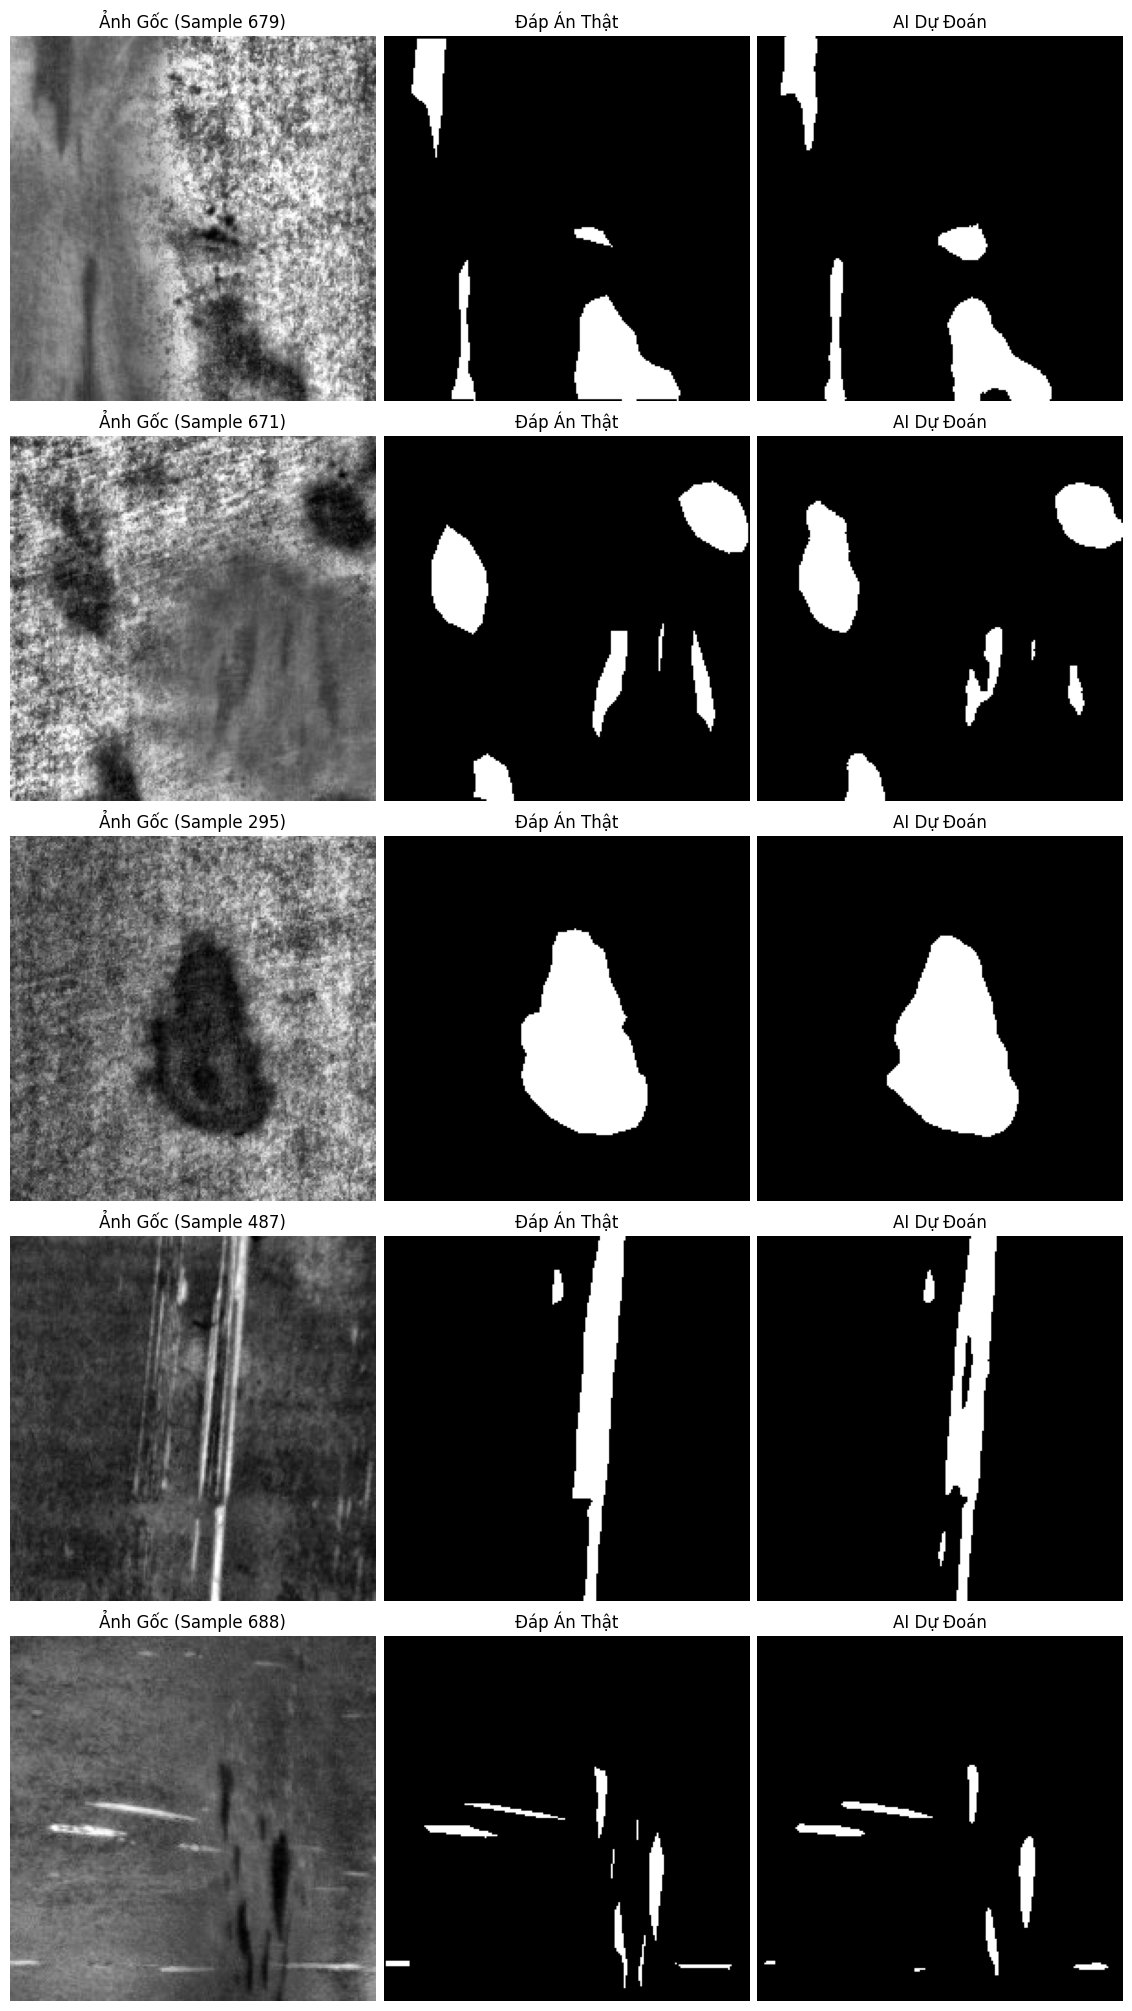

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


best_model = XULite(img_channels=1, num_classes=1).to(device)


checkpoint_path = "best_xulite_model.pth"
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))


best_model.eval()


def visualize_prediction_pytorch(model, dataset, num_samples=5):
    plt.figure(figsize=(12, 4 * num_samples), layout='compressed')


    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        x, y_true = dataset[idx] 


        x_input = x.unsqueeze(0).to(device)


        with torch.no_grad():
            y_pred_logit = model(x_input)
            y_pred_prob = torch.sigmoid(y_pred_logit).squeeze() 


            y_pred_mask = (y_pred_prob > 0.5).float().cpu().numpy()


        x_img = x.squeeze().cpu().numpy()
        y_true_mask = y_true.squeeze().cpu().numpy()


        plt.subplot(num_samples, 3, 3 * i + 1)
        plt.title(f"Ảnh Gốc (Sample {idx})")
        plt.imshow(x_img, cmap='gray')
        plt.axis('off')


        plt.subplot(num_samples, 3, 3 * i + 2)
        plt.title("Đáp Án Thật")
        plt.imshow(y_true_mask, cmap='gray')
        plt.axis('off')


        plt.subplot(num_samples, 3, 3 * i + 3)
        plt.title("AI Dự Đoán")
        plt.imshow(y_pred_mask, cmap='gray')
        plt.axis('off')

    plt.show()

visualize_prediction_pytorch(best_model, val_loader.dataset, num_samples=5)

In [ ]:
!pip install thop
import torch
from thop import profile
from thop import clever_format

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_eval = XULite(img_channels=1, num_classes=1).to(device)
dummy_input = torch.randn(1, 1, 200, 200).to(device)

flops, params = profile(model_eval, inputs=(dummy_input, ), verbose=False)

flops_formatted, params_formatted = clever_format([flops, params], "%.3f")

print(f"Total Parameters: {params_formatted}")
print(f"Total FLOPs: {flops_formatted}")

Total Parameters: 864.545K
Total FLOPs: 229.327M


In [ ]:
def evaluate_segmentation_metrics(model, dataloader, device):
    model.eval()

    TP = 0.0
    FP = 0.0
    FN = 0.0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            # Flatten tensors to 1D arrays for easy comparison
            preds = preds.view(-1)
            masks = masks.view(-1)

            # Calculate True Positives, False Positives, False Negatives
            TP += (preds * masks).sum().item()
            FP += (preds * (1 - masks)).sum().item()
            FN += ((1 - preds) * masks).sum().item()

    # Calculate Metrics based on the formulas in the paper
    epsilon = 1e-7 # Prevent division by zero

    precision = TP / (TP + FP + epsilon)
    recall = TP / (TP + FN + epsilon)

    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)

    # Binary IoU (Intersection over Union for the defect class)
    iou = TP / (TP + FP + FN + epsilon)

    print("=== Segmentation Metrics ===")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1_score:.4f}")
    print(f"mIoU:      {iou:.4f}")

    return iou, f1_score, precision, recall

iou, f1, prec, rec = evaluate_segmentation_metrics(best_model, val_loader, device)

[*] Calculating metrics on Validation Set...
=== Segmentation Metrics ===
Precision: 0.9285
Recall:    0.8863
F1-Score:  0.9069
mIoU:      0.8297


In [ ]:
import time

def measure_fps(model, device, img_size=200, num_iterations=1000):
    model.eval()

    # Create a single dummy image (Batch=1, Channels=1, H=200, W=200)
    dummy_image = torch.randn(1, 1, img_size, img_size).to(device)

    # Warm-up phase (GPU needs a few runs to reach max clock speed)
    print("Warming up GPU...")
    with torch.no_grad():
        for _ in range(100):
            _ = model(dummy_image)

    # Benchmark phase
    print("Measuring FPS...")
    torch.cuda.synchronize() 
    start_time = time.time()

    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_image)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    fps = num_iterations / total_time

    print(f"Total time for {num_iterations} images: {total_time:.3f} seconds")
    print(f"FPS (Frames Per Second): {fps:.2f} img/s")

    return fps

# Run the FPS benchmark
fps_result = measure_fps(best_model, device)

Warming up GPU...
Measuring FPS...
Total time for 1000 images: 7.082 seconds
FPS (Frames Per Second): 141.20 img/s


In [ ]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

979009

In [ ]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


if __name__ == "__main__":
    model = XULite(img_channels=1, num_classes=1)
    total, trainable = count_parameters(model)
    print(f"Total params     : {total:,} ({total/1e6:.3f} M)")
    print(f"Trainable params : {trainable:,} ({trainable/1e6:.3f} M)")

    x = torch.randn(1, 1, 256, 256)

    y = model(x)
    print("Output shape:", y.shape)

Total params     : 979,009 (0.979 M)
Trainable params : 979,009 (0.979 M)
Output shape: torch.Size([1, 1, 256, 256])
